In [1]:
%pip install  -e . 

Obtaining file:///Users/rolandmitric/MASTER_PROGRAMMING_2026/live_notebooks
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for theochem_live (pyproject.toml) ... done
  Created wheel for theochem_live: filename=theochem_live-0.1.0-0.editable-py3-none-any.whl size=2776 sha256=1b03c08cdc831a764b0044aacbe458ba0d01433023cc5ff1fc3e45a88d8ef9e3
  Stored in directory: /private/var/folders/cp/hbk0qs4x4ggb5z_vv2hkmcgw0000gn/T/pip-ephem-wheel-cache-gcgk_8uw/wheels/a8/61/bd/318087ecc54d7e0ca7146aa39c26758304348afc27f0ad3eb7
Successfully built theochem_live
  Attempting uninstall: theochem_live
    Found existing installation: theochem_live 0.1.0
    Uninstalling theochem_live-0.1.0:
      Successfully uninstalled theochem_live-0.1.0

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: 

In [6]:
from src_live import Molecule, BasisSet, ELEMENT_SYMBOL, Shell, S, T, V, ERI, MolecularIntegrals

In [7]:
benzene_xyz = """12
Benzene molecule
C 0.000000 1.402720 0.000000
C 1.214790 0.701360 0.000000
C 1.214790 -0.701360 0.000000
C 0.000000 -1.402720 0.000000
C -1.214790 -0.701360 0.000000
C -1.214790 0.701360 0.000000
H 0.000000 2.490290 0.000000
H 2.156660 1.245150 0.000000
H 2.156660 -1.245150 0.000000
H 0.000000 -2.490290 0.000000
H -2.156660 -1.245150 0.000000
H -2.156660 1.245150 0.000000
"""

In [8]:
benzene = Molecule.from_string(benzene_xyz)
sto3g = BasisSet("sto-3g")
sto3g.download_from_bse(["C", "H"])
print(sto3g)

Dump data to sto-3g.json
Basis set: sto-3g
Element: H
l = 0, exponents = [3.42525091 0.62391373 0.1688554 ], coefficients = [0.15432897 0.53532814 0.44463454]
Element: C
l = 0, exponents = [71.61683735 13.04509632  3.53051216], coefficients = [0.15432897 0.53532814 0.44463454]
l = 0, exponents = [2.94124936 0.6834831  0.22228992], coefficients = [-0.09996723  0.39951283  0.70011547]
l = 1, exponents = [2.94124936 0.6834831  0.22228992], coefficients = [0.15591627 0.60768372 0.39195739]



In [9]:
molints = MolecularIntegrals(benzene, sto3g)
S_my = molints.overlap_matrix()
T_my = molints.kinetic_matrix()
V_my = molints.nuclear_attraction_matrix()
ERI_my = molints.electron_repulsion_tensor()


Text(0.5, 1.0, 'log$_{10}$ |ERI|')

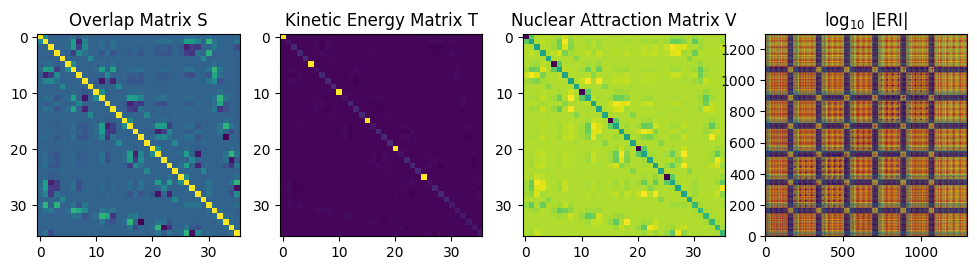

In [12]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 4, figsize = (12, 6))  

axes[0].imshow(S_my, cmap = "viridis")
axes[1].imshow(T_my, cmap = "viridis")
axes[0].set_title("Overlap Matrix S")
axes[1].set_title("Kinetic Energy Matrix T")
axes[2].imshow(V_my, cmap = "viridis")
axes[2].set_title("Nuclear Attraction Matrix V")


n = ERI_my.shape[0]
ERI2 = ERI_my.reshape(n * n, n * n)

im = axes[3].imshow(
    np.log10(np.abs(ERI2) + 1e-16),
    cmap="jet",
    origin="lower",
)
axes[3].set_title(r"log$_{10}$ |ERI|")


In [ ]:
from __future__ import annotations
from dataclasses import dataclass

class RHF:
    def __init__(self, molecule: Molecule, 
                 molints: MolecularIntegrals, 
                 max_cycle: int = 100,
                 conv_tol: float = 1e-8) -> None:
        self.molecule = molecule
        self.molints = molints
        self.max_cycle = max_cycle
        self.conv_tol = conv_tol

        self.nel = molecule.n_electrons
        self.nocc = self.nel // 2

    def initialize(self):
        self.S = self.molints.overlap_matrix()
        print(self.S[0:10, 0:10])
        self.T = self.molints.kinetic_matrix()
        self.V = self.molints.nuclear_attraction_matrix()
        #self.twoel = self.molints.electron_repulsion_tensor()

        eigval, eigvec = np.linalg.eigh(self.S)
        if np.any(eigval < 1e-12):
            raise ValueError("Overlap matrix is singular or nearly singular.")

        self.X = eigvec @ np.diag(eigval**-0.5) 
        self.hcore = self.T + self.V
        hcore_orhto = self.X.T @ self.hcore @ self.X
        _, c_ortho = np.linalg.eigh(hcore_orhto)
        c_occ = self.X @ c_ortho[:, :self.nocc]
        self.P = c_occ @ c_occ.T


In [32]:
rhf = RHF(benzene, molints)
rhf.initialize()

[[ 1.00000000e+00  2.48362397e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  8.12514843e-07  3.72661945e-02 -5.35130474e-02
   3.08958017e-02  0.00000000e+00]
 [ 2.48362397e-01  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  3.72661945e-02  3.63285106e-01 -3.35070845e-01
   1.93453426e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  5.35130474e-02  3.35070845e-01 -1.92871044e-01
   2.33739801e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00 -3.08958017e-02 -1.93453426e-01  2.33739801e-01
   7.70279169e-02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  2.11977782e-01]
 [ 8.12514843e-07  3.72661945e-02  5.35130474e-02 -3.08958017e-02
   0.00000000e+00  1.00000000e+00  2.48362397e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00